In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
from datetime import datetime

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from src.Alpha9.pipeline.data_handler import DataHandler
from src.Alpha9.market.events import EventQueue, MarketEvent, SignalEvent
from src.Alpha9.strategy.model import Model
from src.Alpha9.strategy.predict import Strategy
from src.Alpha9.strategy.risk.risk_manager import RiskManager
from src.Alpha9.strategy.position.portfolio import Portfolio
from src.Alpha9.utility import get_config, get_path, read_file

In [4]:
config = get_config.load()
data = read_file.read_data('train', 'data')

In [5]:
SYMBOLS = [symbol.split('/')[0] for symbol in config['pipeline']['symbols']]
date_format = "%Y-%m-%d %H:%M:%S"
START_DATE = datetime.strptime("2022-01-01 00:00:00", date_format)
END_DATE = datetime.strptime("2022-01-31 23:59:59", date_format)

capital = config['backtest']['capital']
transaction_cost_fraction = config['market']['transaction_cost_fraction']
bankruptcy_fraction = config['strategy']['bankruptcy_fraction']
slippage_cost_fraction = config['strategy']['slippage_cost_fraction']
stop_loss_multiple = config['strategy']['stop_loss_multiple']
stop_loss_portion = config['strategy']['stop_loss_portion']
take_profit_multiple = config['strategy']['take_profit_multiple']
take_profit_portion = config['strategy']['take_profit_portion']

seq_length = config['strategy']['sequence_length']
model_dir = get_path.absolute(config['path']['strategy']['model'])
portfolio_dir = get_path.absolute(config['path']['strategy']['portfolio'])
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [6]:
event_q = EventQueue()
data_handler = DataHandler(data, SYMBOLS, event_q, START_DATE, END_DATE)
model = Model(SYMBOLS, model_dir)
strategy = Strategy(data_handler, event_q, model, SYMBOLS, seq_length, device)
risk_m = RiskManager(data_handler, SYMBOLS, slippage_cost_fraction, stop_loss_multiple, stop_loss_portion, take_profit_multiple, take_profit_portion)
portf = Portfolio(SYMBOLS, data_handler, event_q, risk_m, capital, bankruptcy_fraction, portfolio_dir)

In [7]:
N = 5
for _ in range(N):
    data_handler.update_candles()

In [8]:
data_handler.get_latest_candle()

(open, BNB)                 518.100000
(high, BNB)                 518.500000
(low, BNB)                  514.800000
(close, BNB)                515.000000
(volume, BNB)             13355.034000
                              ...     
(vwap, SOL)                 172.698660
(mfi, SOL)                   31.410603
(log-return, SOL)            -0.008420
(vol-spike, SOL)             -0.462501
(norm-volatility, SOL)        0.009388
Name: 2022-01-01 04:00:00, Length: 96, dtype: float64

In [9]:
data_handler.get_latest_candles(3)

,"(open, BNB)","(high, BNB)","(low, BNB)","(close, BNB)","(volume, BNB)","(macd-signal-pct, BNB)","(macd-slope, BNB)","(sar, BNB)","(tema, BNB)","(ppo, BNB)",...,"(adx, SOL)","(stoch-rsi, SOL)","(bop, SOL)","(natr, SOL)","(obv, SOL)","(vwap, SOL)","(mfi, SOL)","(log-return, SOL)","(vol-spike, SOL)","(norm-volatility, SOL)"
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-01-01 02:00:00,517.2,519.3,517.1,517.8,10209.673,0.000539,0.337537,-0.005413,0.005772,-0.418497,...,20.733553,1.621002,0.029851,1.217879,77556129.03,172.668043,36.595608,0.000116,-0.590311,0.003878
2022-01-01 03:00:00,517.8,518.8,517.3,518.1,9973.326,0.000898,0.302219,-0.003667,0.004210,-0.502750,...,19.635482,1.835789,0.281250,1.156078,77575114.25,172.677441,36.182999,0.001099,-0.540048,0.003701
2022-01-01 04:00:00,518.1,518.5,514.8,515.0,13355.034,0.000722,-0.000122,-0.008350,-0.001313,-0.573404,...,18.543217,-12.631871,-0.919255,1.149637,77553220.13,172.698660,31.410603,-0.008420,-0.462501,0.009388


In [10]:
data_handler.get_latest_candle_datetime()

Timestamp('2022-01-01 04:00:00')

In [11]:
val = ('sar', 'BNB')
data_handler.get_latest_candle_value(val)

np.float64(-0.0083495145631067)

In [12]:
data_handler.get_latest_candles_value(val, 3)

timestamp
2022-01-01 02:00:00   -0.005413
2022-01-01 03:00:00   -0.003667
2022-01-01 04:00:00   -0.008350
Name: (sar, BNB), dtype: float64

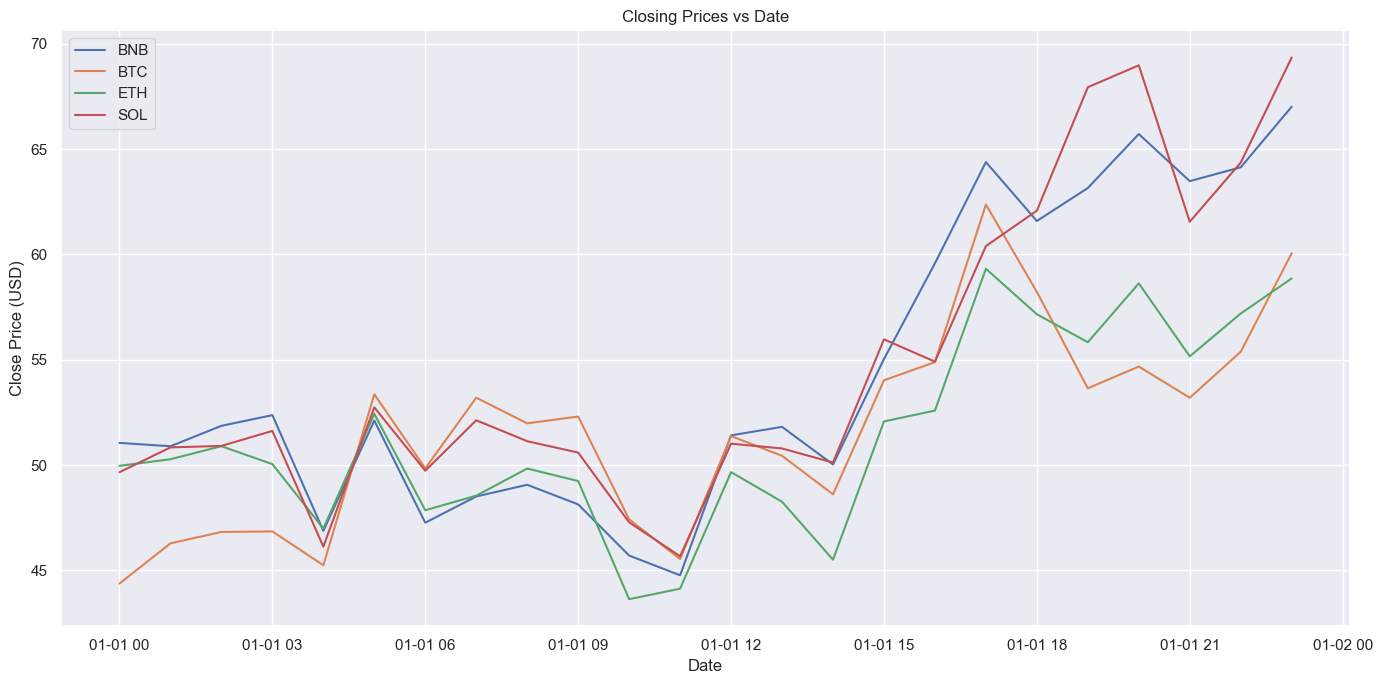

In [13]:
data_handler.visualize_data('rsi')

In [14]:
events_processed = 0
fiducias = []

In [15]:
while data_handler.continue_backtest:
    data_handler.update_candles()
    while not event_q.empty():
        event = event_q.get_event()
        events_processed += 1
        if isinstance(event, MarketEvent):
            strategy.calculate_fiducia(event)
        elif isinstance(event, SignalEvent):
            fiducias.append(event.fiducia)

In [16]:
events_processed

48

In [17]:
fiducias

[{'BNB': 0.20000000298023224,
  'BTC': 0.20000000298023224,
  'ETH': 0.20000000298023224,
  'SOL': 0.20000000298023224},
 {'BNB': 0.20000000298023224,
  'BTC': 0.20000000298023224,
  'ETH': 0.20000000298023224,
  'SOL': 0.20000000298023224},
 {'BNB': 0.20000000298023224,
  'BTC': 0.20000000298023224,
  'ETH': 0.20000000298023224,
  'SOL': 0.20000000298023224},
 {'BNB': 0.20000000298023224,
  'BTC': 0.20000000298023224,
  'ETH': 0.20000000298023224,
  'SOL': 0.20000000298023224},
 {'BNB': 0.20000000298023224,
  'BTC': 0.20000000298023224,
  'ETH': 0.20000000298023224,
  'SOL': 0.20000000298023224},
 {'BNB': 0.20000000298023224,
  'BTC': 0.20000000298023224,
  'ETH': 0.20000000298023224,
  'SOL': 0.20000000298023224},
 {'BNB': 0.20000000298023224,
  'BTC': 0.20000000298023224,
  'ETH': 0.20000000298023224,
  'SOL': 0.20000000298023224},
 {'BNB': 0.20000000298023224,
  'BTC': 0.20000000298023224,
  'ETH': 0.20000000298023224,
  'SOL': 0.20000000298023224},
 {'BNB': 0.20000000298023224,
  